# **🛡️ RiskLens**: *Calibrated Default Probability Scoring with Business-Driven Decision Thresholds*


Financial institutions lose billions every year due to loan defaults. Traditional credit assessment processes often rely on static rules and manual reviews, making it difficult to consistently identify high-risk applicants.

RiskLens is an end-to-end credit risk decisioning system that predicts the probability of loan default, calibrates risk estimates, optimizes lending thresholds using business costs, and generates explainable lending decisions.

This notebook focuses on understanding the dataset through exploratory data analysis (EDA). The goal is to assess data quality, understand feature distributions, identify class imbalance, and uncover patterns that may influence default behavior.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

##  Data Loading

Load the loan default dataset and inspect its overall structure before performing any analysis.

In [2]:
df = pd.read_csv("Loan_default.csv")
df.shape

(255347, 18)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df.isnull().sum()


,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [6]:
print(df.duplicated().sum())

0


In [7]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

## Feature Exploration

Examine numerical and categorical variables to understand their distributions and characteristics.

In [8]:
num_cols=["Age", 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio']
cat_cols=[ 'Education','EmploymentType','MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
print(len(num_cols))
print(len(cat_cols))

9
7


In [9]:
df[num_cols].describe()


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000


In [10]:
df[num_cols].skew()

,0
Age,0.000698
Income,-0.000381
LoanAmount,-0.001827
CreditScore,0.004688
MonthsEmployed,-0.002142
NumCreditLines,-0.000278
InterestRate,0.004608
LoanTerm,-0.002178
DTIRatio,-0.001499


In [11]:
df[cat_cols].describe()

,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347
unique,4,4,3,2,2,5,2
top,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,64366,64161,85302,127677,127742,51298,127701


In [12]:
for col in cat_cols:
  print(col)
  print(df[col].value_counts())
  print('-'*50)

Education
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64
--------------------------------------------------
EmploymentType
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64
--------------------------------------------------
MaritalStatus
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64
--------------------------------------------------
HasMortgage
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64
--------------------------------------------------
HasDependents
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64
--------------------------------------------------
LoanPurpose
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64
--------------------------------------------------
Has

## Target Variable Analysis

Analyze the distribution of the target variable (Default) to assess class imbalance and understand the modeling challenge.

In [13]:
df["Default"].value_counts()


,count
Default,
0,225694
1,29653


In [14]:
df["Default"].value_counts(normalize=True)*100

,proportion
Default,
0,88.387175
1,11.612825


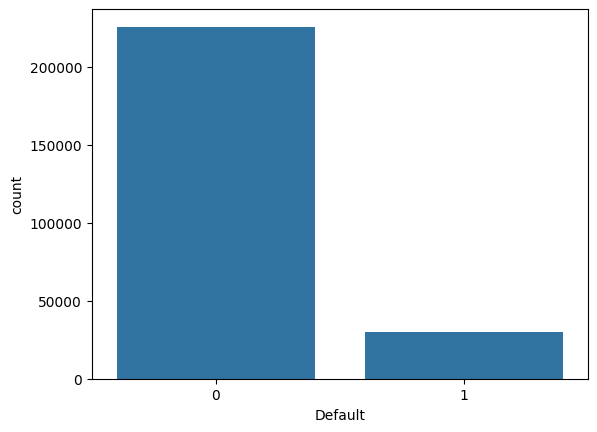

In [15]:
sns.countplot(
    data=df,
    x="Default"
)
plt.show()

## Numerical Feature Distributions

Visualize numerical features to identify skewness, unusual patterns, and potential transformation requirements.

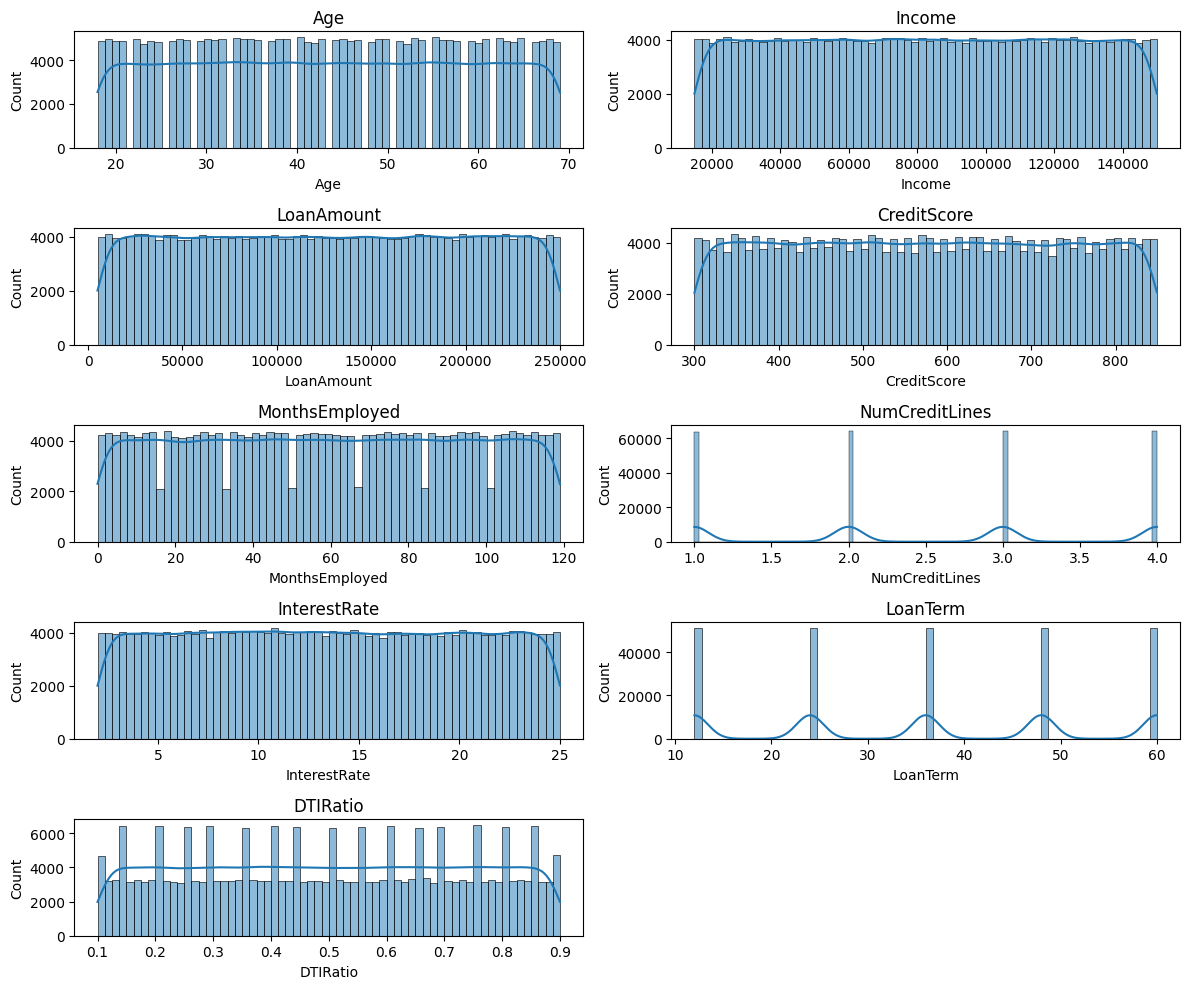

In [16]:
plt.figure(figsize=(12,10))
for i, col in enumerate(num_cols):
  plt.subplot(len(num_cols)//2+1,2,i+1)
  sns.histplot(
      df[col],
      kde=True
    )
  plt.title(col)
plt.tight_layout()
plt.show()


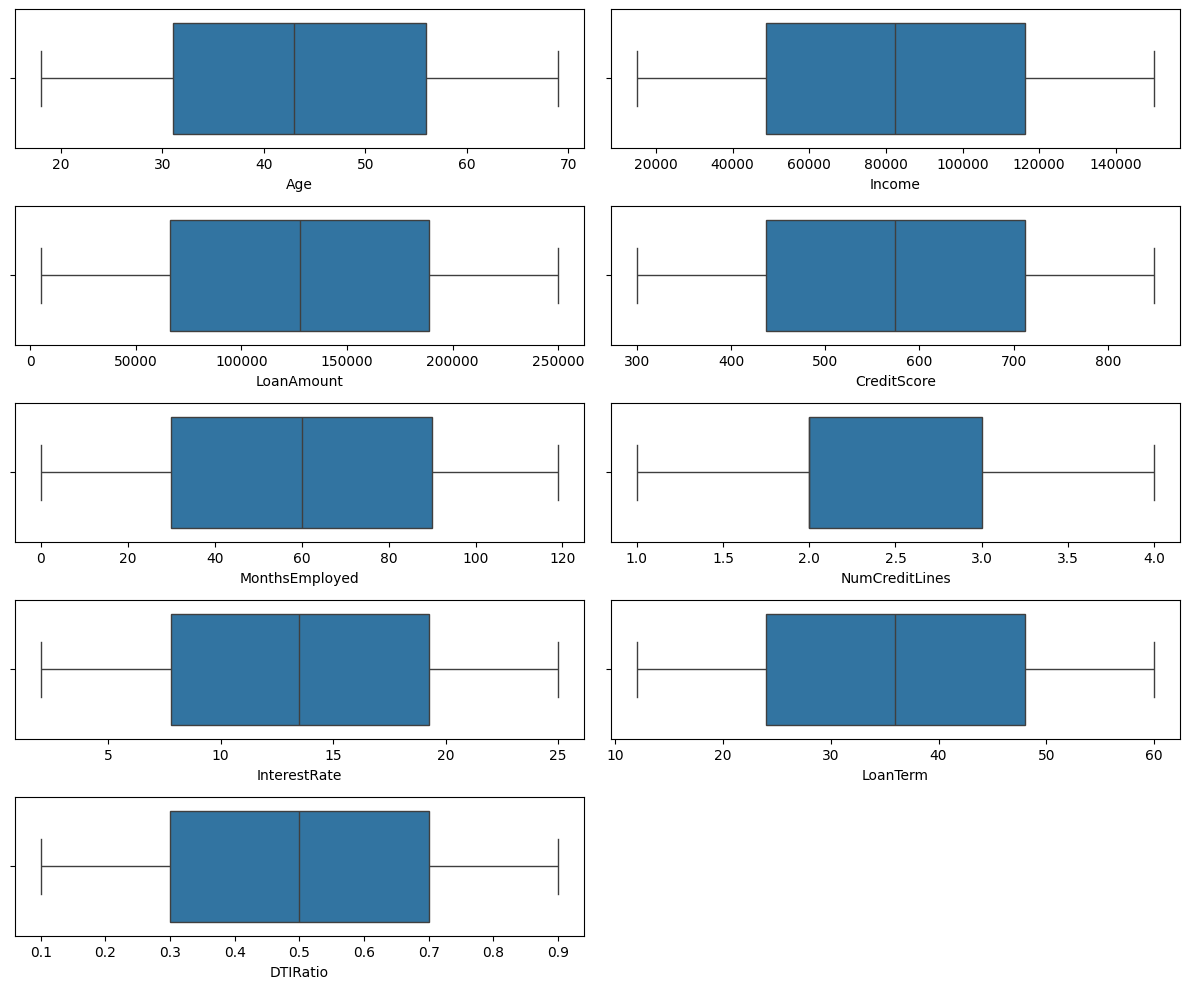

In [17]:
plt.figure(figsize=(12,10))
for i,col in enumerate(num_cols):
  plt.subplot(len(num_cols)//2+1,2,i+1)
  sns.boxplot(x=df[col])
plt.tight_layout()
plt.show()

## Outlier Analysis

Use boxplots and the IQR method to identify extreme observations that may influence model behavior.

In [18]:
for col in num_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR

  outliers=((df[col]<lower_limit) | (df[col]>upper_limit)).sum()
  print(f"{col}: {outliers}")

Age: 0
Income: 0
LoanAmount: 0
CreditScore: 0
MonthsEmployed: 0
NumCreditLines: 0
InterestRate: 0
LoanTerm: 0
DTIRatio: 0


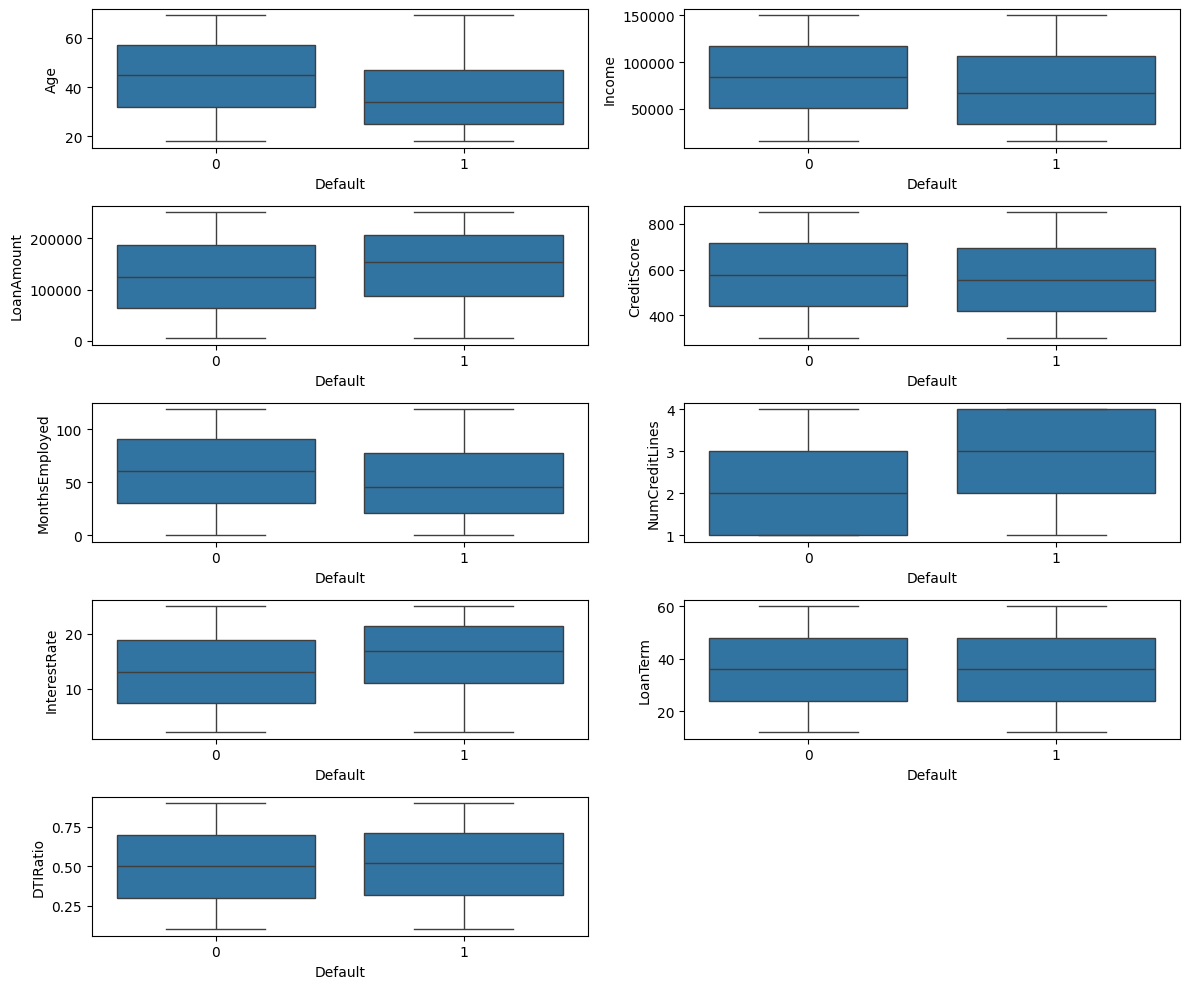

In [19]:
plt.figure(figsize=(12,10))
for i,col in enumerate(num_cols):
  plt.subplot(len(num_cols)//2+1,2,i+1)
  sns.boxplot(x="Default",y=col, data=df)
plt.tight_layout()
plt.show()

## Feature Relationships

Examine correlations between numerical features to identify redundancy and understand relationships within the data.

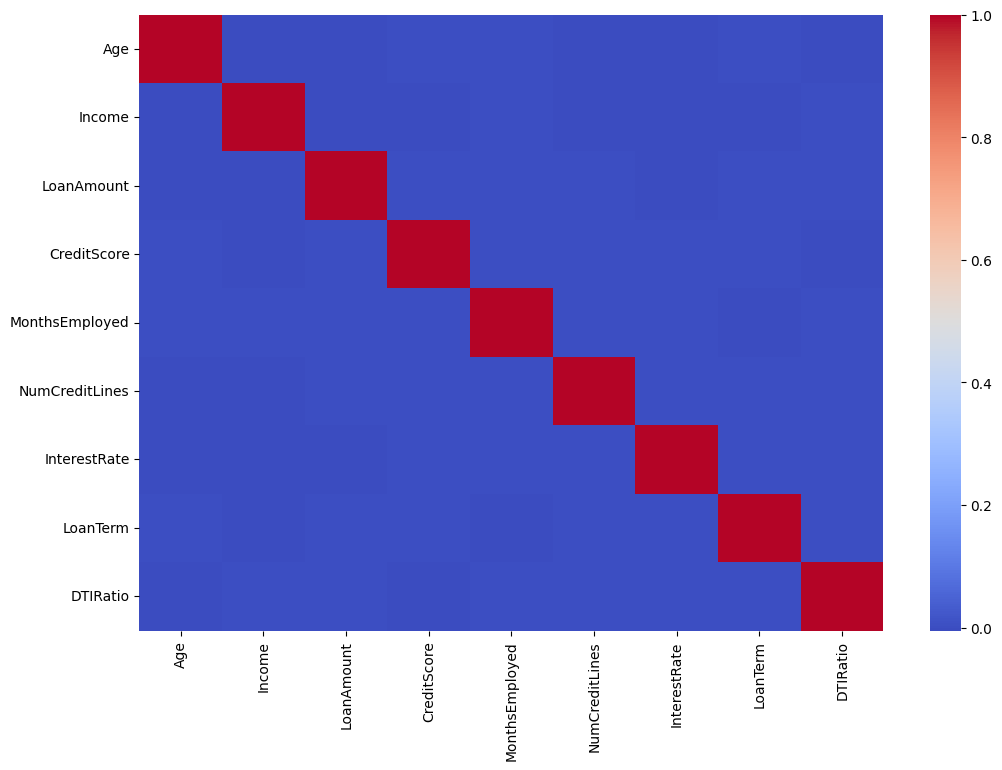

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df[num_cols].corr(),
    cmap="coolwarm",
    annot=False
)
plt.show()

## Categorical Features vs Default

Investigate how categorical variables relate to loan default behavior.

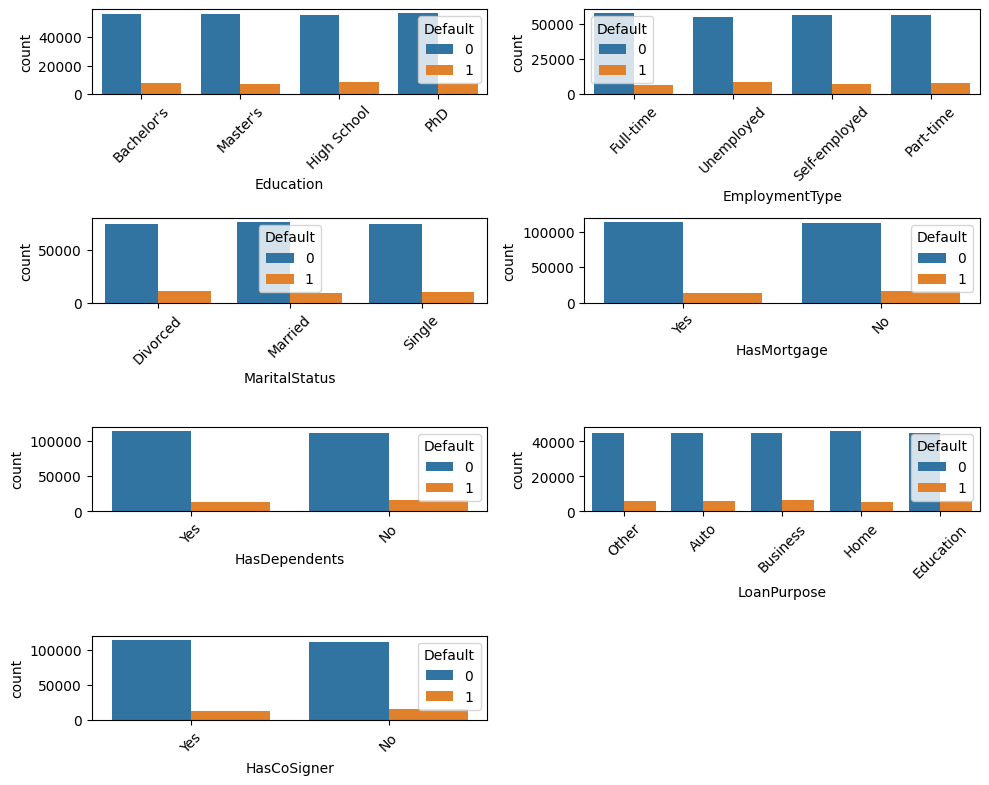

In [21]:
plt.figure(figsize=(10,8))
for i,col in enumerate(cat_cols):
  plt.subplot(len(cat_cols)//2+1,2,i+1)
  sns.countplot(
      data=df,
      x=col,
      hue="Default"
  )
  plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Default Rate Analysis by Category

Measure the default rate within each category to identify potential risk indicators.

In [22]:
for col in cat_cols:
 print( pd.crosstab(
      df[col],
      df["Default"],
      normalize="index"
  )*100)
 print("-"*20)

Default              0          1
Education                        
Bachelor's   87.898891  12.101109
High School  87.121105  12.878895
Master's     89.128279  10.871721
PhD          89.414042  10.585958
--------------------
Default                 0          1
EmploymentType                      
Full-time       90.536634   9.463366
Part-time       88.034787  11.965213
Self-employed   88.537971  11.462029
Unemployed      86.447105  13.552895
--------------------
Default                0          1
MaritalStatus                      
Divorced       87.467219  12.532781
Married        89.602823  10.397177
Single         88.087564  11.912436
--------------------
Default              0          1
HasMortgage                      
No           87.654892  12.345108
Yes          89.119419  10.880581
--------------------
Default                0          1
HasDependents                      
No             87.275577  12.724423
Yes            89.497581  10.502419
--------------------
Default  

In [23]:
eda_summary={
    "Rows":len(df),
    "Columns":len(df.columns),
    "Missing Values":df.isnull().sum().sum(),
    "Duplicate Values":df.duplicated().sum(),
    "Numerical Features":len(num_cols),
    "Categorical Features":len(cat_cols),
    "Class Distribution":df["Default"].value_counts(normalize=True).to_dict(),

}
eda_summary

{'Rows': 255347,
 'Columns': 18,
 'Missing Values': np.int64(0),
 'Duplicate Values': np.int64(0),
 'Numerical Features': 9,
 'Categorical Features': 7,
 'Class Distribution': {0: 0.8838717509898295, 1: 0.11612824901017048}}

## Key Findings

- The dataset contains both numerical and categorical applicant attributes relevant to credit risk assessment.
- No significant missing-value issues were identified.
- The target variable is imbalanced, indicating that accuracy alone may not be a reliable evaluation metric.
- Several features exhibit varying distributions across applicants and may contribute differently to default risk.
- Outlier analysis and correlation assessment provide valuable context for preprocessing and model development.

The insights gathered in this notebook will guide feature preparation and model building in the next stage of the RiskLens pipeline.